In [1]:
import pandas as pd
import numpy as np

import tubesml as tml


import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss

from source.report import report_points, report_victory, _point_to_proba


from sklearn.model_selection import KFold

from sklearn.linear_model import Ridge, LogisticRegression, Lasso
from sklearn.pipeline import Pipeline

import lightgbm as lgb
import xgboost as xgb

In [2]:
def train_predict(data, test_data, target, estimator, cv, test_target=None, fit_params=None, early_stopping=False, shap=True, result_compare=None):
    cv_score = tml.CrossValidate(data=data, target=target, test=test_data,
                                 estimator=estimator, cv=cv, fit_params=fit_params, early_stopping=early_stopping,
                                shap=shap, imp_coef=True, predict_proba=True, regression=False)

    oof, pred, result_dict = cv_score.score()

    score = brier_score_loss(y_true=target, y_prob=oof)
    print(f"OOF score: {score}")

    if early_stopping:
        print(result_dict["iterations"])

    if shap:
        tml.plot_feat_imp(result_dict["feat_imp"], imp="both", n=10)
        to_plot = result_dict["feat_imp"].head(10)["Feature"].to_list()
        tml.plot_shap_values(result_dict["shap_values"], features=to_plot)
    else:
        tml.plot_feat_imp(result_dict["feat_imp"], imp="standard", n=10)

    tml.eval_classification(data=data, target=target, preds=oof,
                        proba=True, thrs=0.5, plot=True, feat="delta_Seed")

    if result_compare is not None:
        baseline = result_compare["score"]
        ref_oof = result_compare["oof"]

        if score - baseline >= 0:
            print(f"This is {round((score - baseline) / baseline * 100, 3)}% worse than the baseline.")
        else:
            print(f"This is {round(-(score - baseline) / baseline * 100, 3)}% better than the baseline.")
    
        comparison = tml.CompareModels(data=data, true_label=target.reset_index(drop=True),
                                       pred_1=oof, pred_2=ref_oof,
                                       kfold=cv,
                                       regression=True,
                                       probabilities=True,
                                       metric_func=mean_squared_error)
    
        comparison.compare_metrics()
        comparison.compare_predictions()
        comparison.statistical_significance()

    if test_target is not None:
        score = brier_score_loss(y_true=test_target, y_prob=pred)
        print(f"Test score: {score}")
        tml.eval_classification(data=data, target=target, preds=oof,
                        proba=True, thrs=0.5, plot=True, feat="delta_Seed")

    return oof, pred, result_dict

In [5]:
df = pd.read_csv("data/processed/women_training.csv")

DROP = ["target", "target_points", "ID", "DayNum", "Team1", "Team2",
        'T1_Loc', 'T2_Loc',
                "T1_region", "T2_region", "Season", "delta_Loc",
                "Season", "competitive", "competitive_score",
                "delta_def_rating_diff", "delta_impact_diff",
                "T1_def_rating_diff", "T2_def_rating_diff"]


N_FOLDS = 5
kfolds = KFold(n_splits=N_FOLDS, shuffle=True, random_state=13)

df_train, df_test = tml.make_test(df, test_size=0.2, random_state=34)

In [14]:
result_dict["feat_imp"].head(20)["Feature"].tolist()

['delta_Seed',
 'delta_quality',
 'delta_FGM2',
 'delta_N_wins',
 'delta_True_shooting_perc_diff',
 'delta_off_rating',
 'delta_FGM_perc',
 'delta_OR_opportunity',
 'delta_possessions_diff',
 'delta_FGM_diff',
 'delta_off_edge',
 'delta_Score_diff',
 'delta_Blk',
 'delta_Blk_diff',
 'delta_OT_win_perc',
 'delta_FGM',
 'delta_OR_opportunity_diff',
 'delta_Ast_TO_ratio_diff',
 'delta_off_rating_diff',
 'delta_Ast_diff']

OOF score: 0.14629790597653092
[658, 586, 1182, 507, 913]


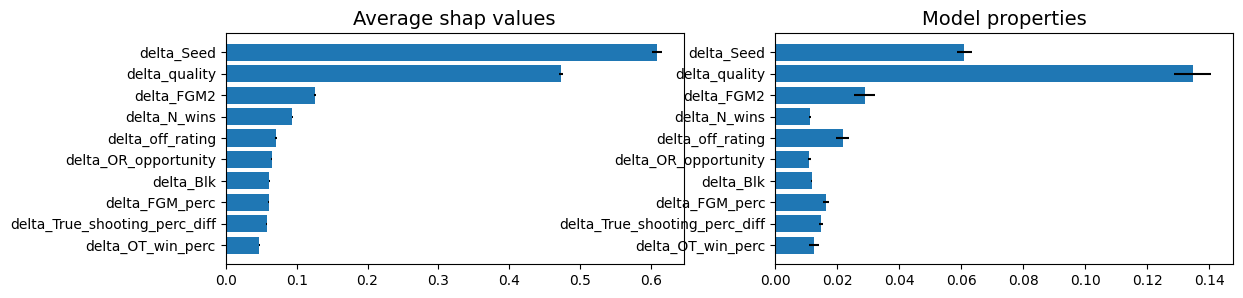

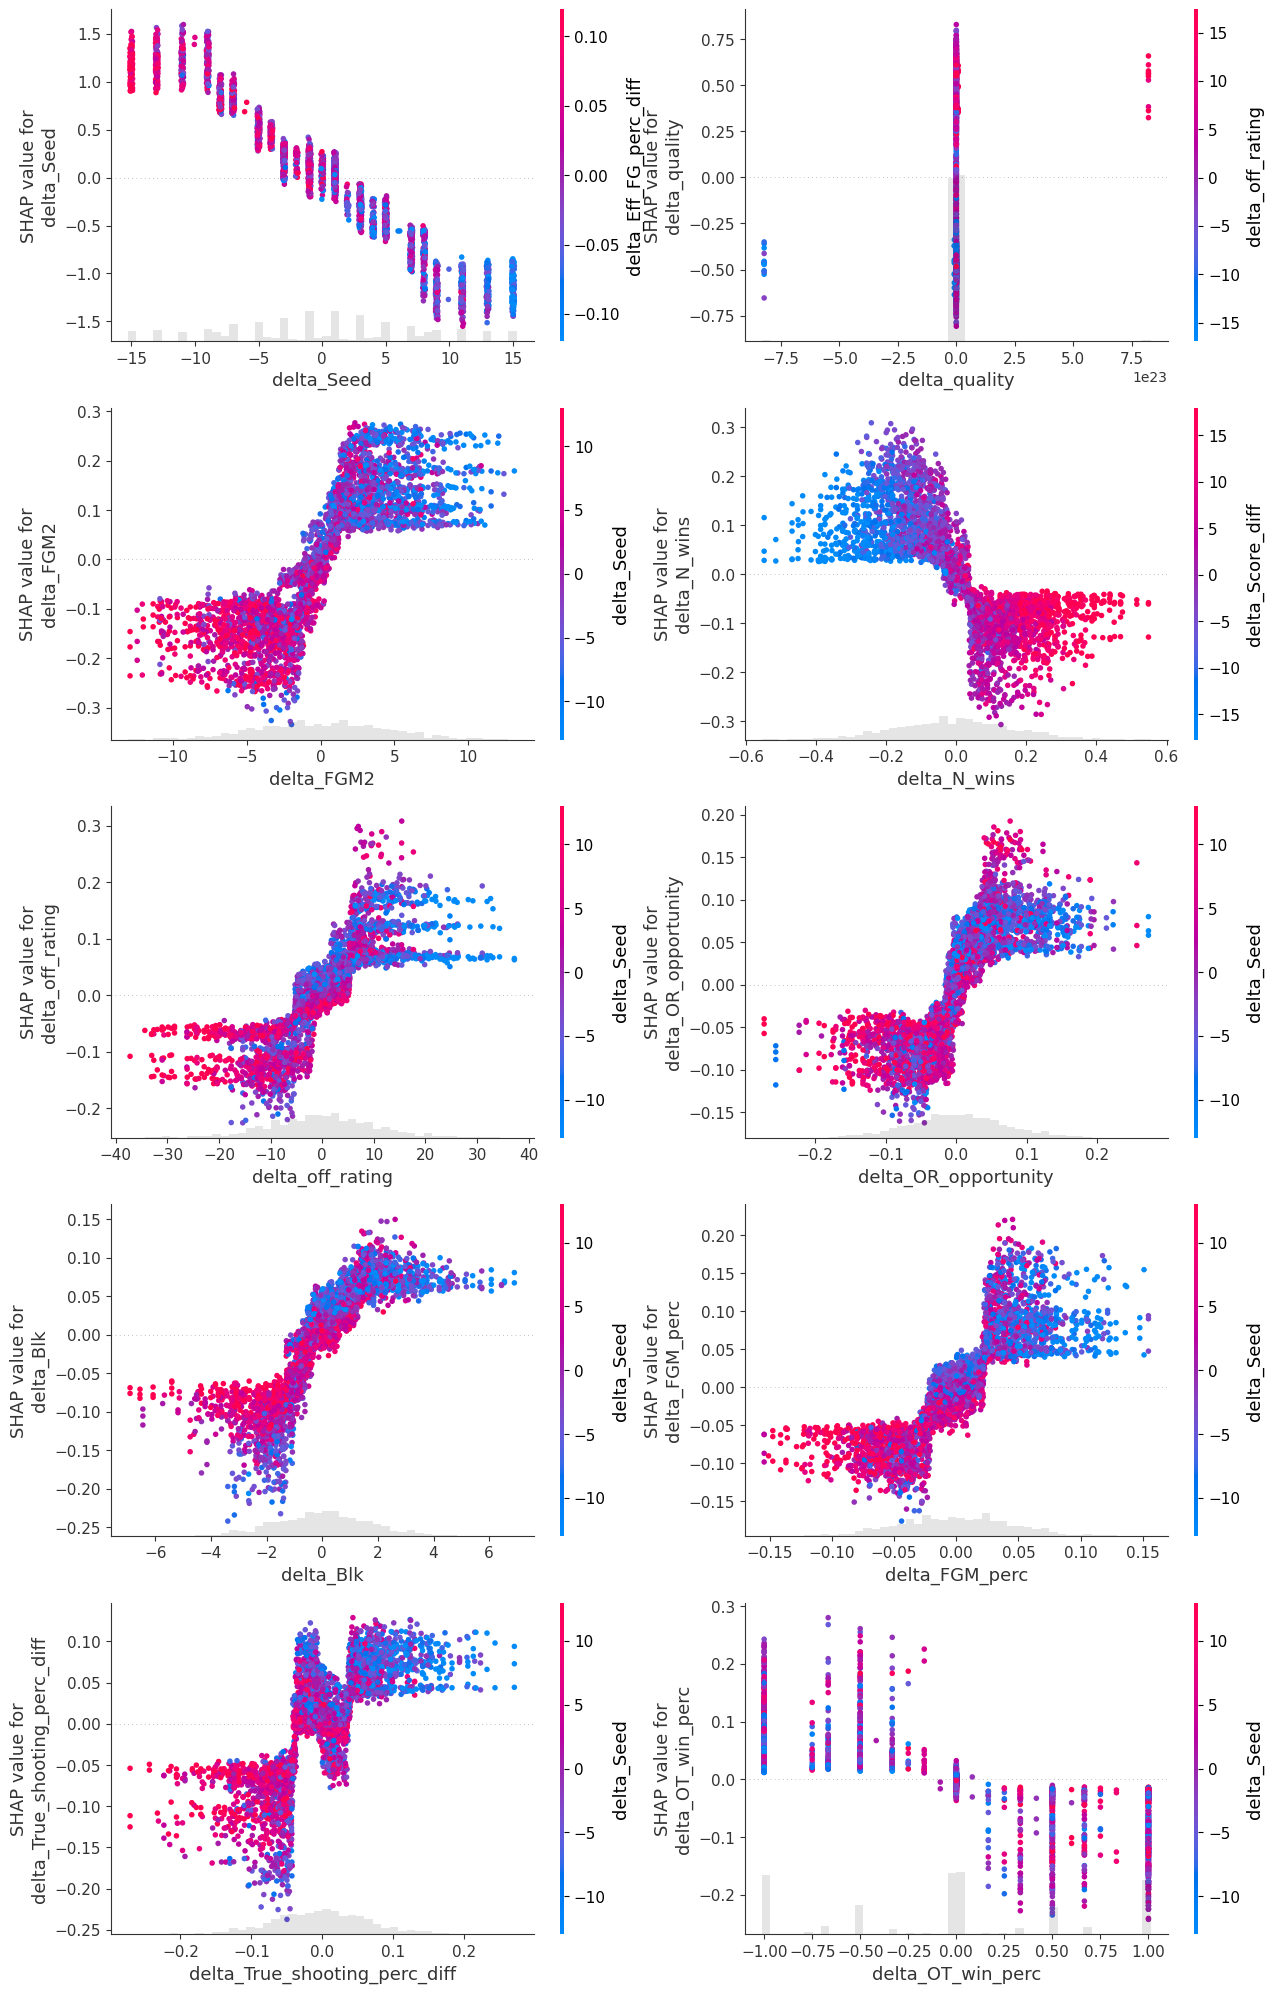

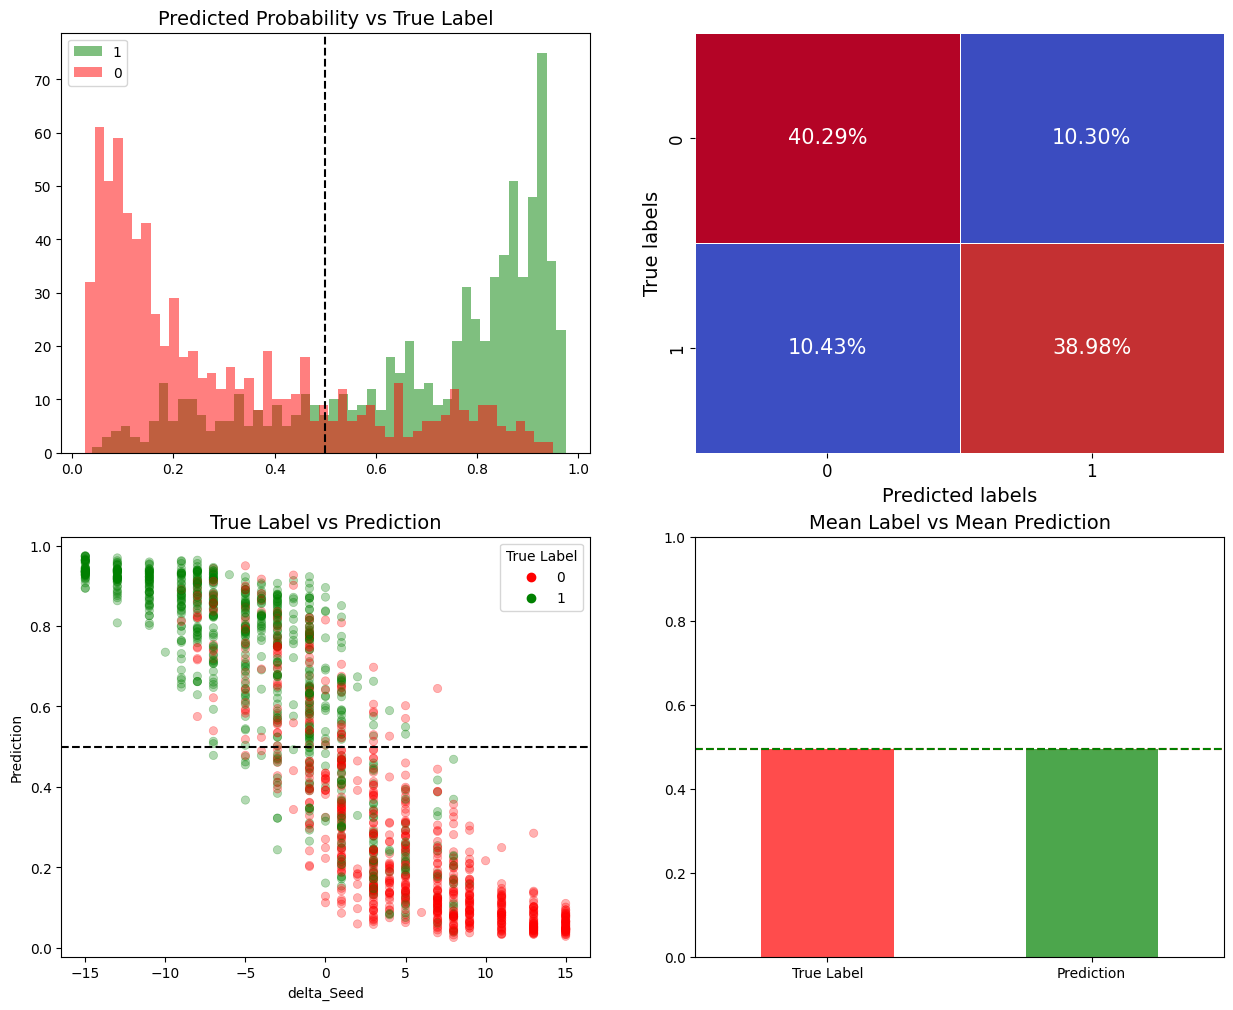

Accuracy score: 	0.7927
AUC ROC: 		0.8721
              precision    recall  f1-score   support

           0       0.79      0.80      0.80       771
           1       0.79      0.79      0.79       753

    accuracy                           0.79      1524
   macro avg       0.79      0.79      0.79      1524
weighted avg       0.79      0.79      0.79      1524

Test score: 0.1428603491512395


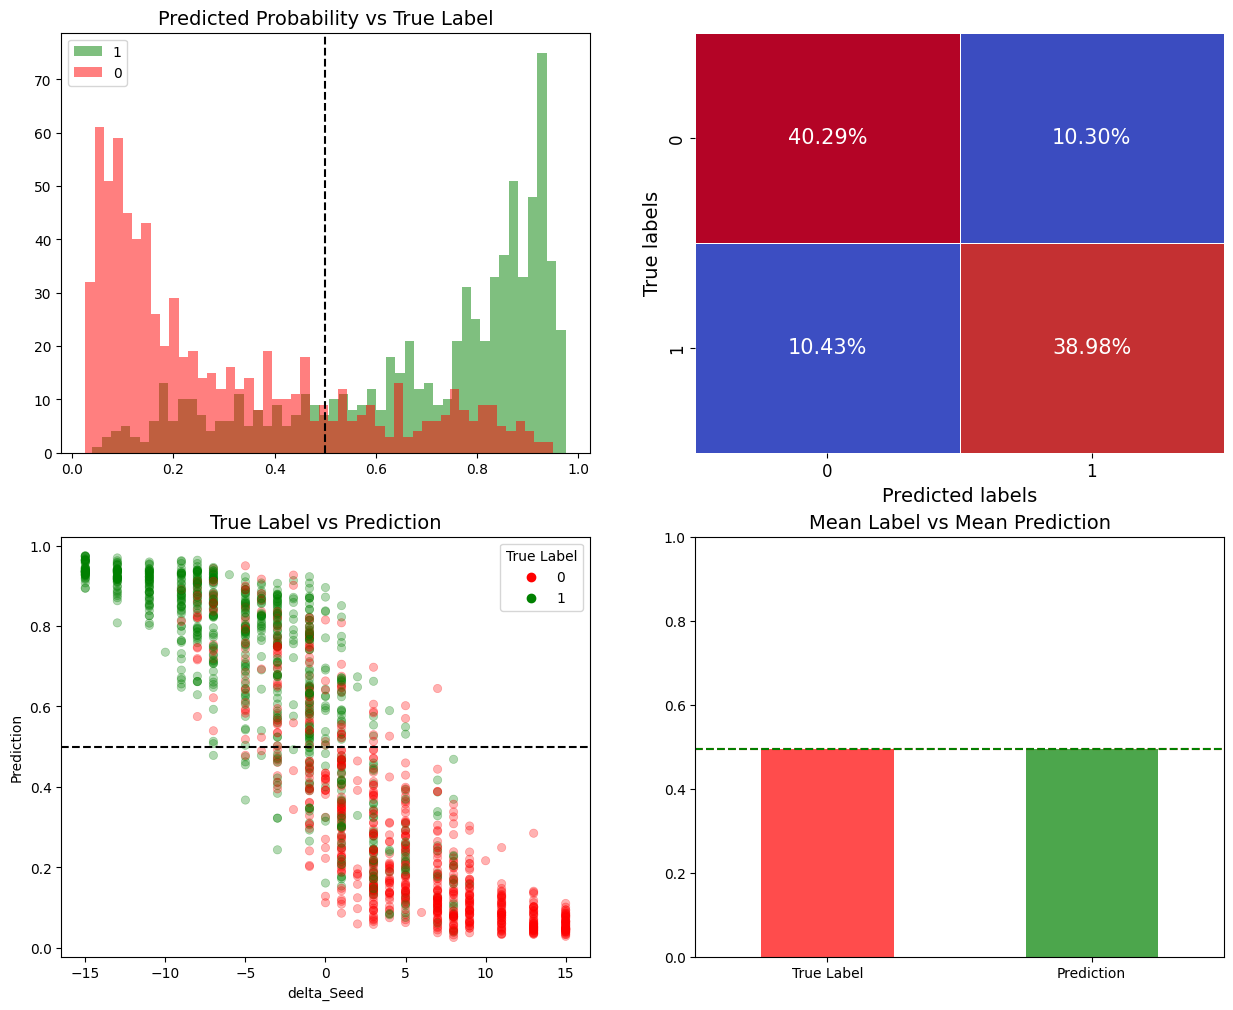

Accuracy score: 	0.7927
AUC ROC: 		0.8721
              precision    recall  f1-score   support

           0       0.79      0.80      0.80       771
           1       0.79      0.79      0.79       753

    accuracy                           0.79      1524
   macro avg       0.79      0.79      0.79      1524
weighted avg       0.79      0.79      0.79      1524

Accuracy train: 		 0.7927
Accuracy test: 			 0.801
Logloss train: 			 0.4501
Logloss test: 			 0.4439
Brier train: 			 0.1463
Brier test: 			 0.1429
Unsure train: 			 12.9921%
Unsure test: 			 16.4921%


,acc_oof,acc_test,logloss_oof,logloss_test,unsure_oof,unsure_test,brier_oof,brier_test
0,0.7927,0.801,0.4501,0.4439,12.9921,16.4921,0.1463,0.1429


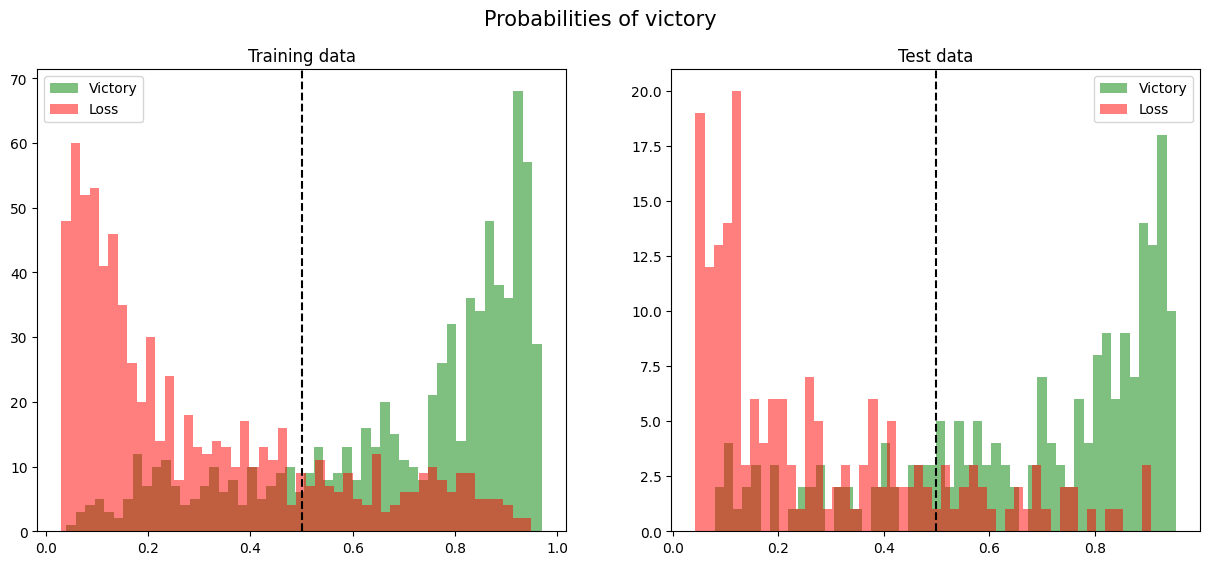

In [17]:
target = df_train["target"]

not_imp = [

 ]

extras = [#"T1_Opp_True_shooting_perc", "T2_Opp_True_shooting_perc",
          "T1_Seed", "T2_Seed",
          #"T1_impact", "T2_impact", "T1_FGM3_perc", "T2_FGM3_perc"
          ]
FEATURES = [c for c in df_train if c not in DROP and "delta" in c and c not in not_imp]
train = df_train[FEATURES].copy()
test_target = df_test["target"]
test = df_test[FEATURES].copy()

model = xgb.XGBClassifier(random_state=34, n_jobs=-1, n_estimators=10000,
                              learning_rate=0.01,
                             subsample=0.777,
                            colsample_bytree=0.666,
                            reg_alpha=0.005,
                            reg_lambda=24.63,
                            max_depth=45,
                            colsample_bylevel=0.947,
                            min_child_weight=9.43,
                            early_stopping_rounds=1000,
                             eval_metric="auc")

pipe = Pipeline([
                ("imp", tml.DfImputer()),
                ("model", model)])

    
fit_params = {"verbose": False}

oof, pred, result_dict = train_predict(data=train, test_data=test, target=target,
                                       estimator=pipe, cv=kfolds, test_target=test_target,
                                       fit_params=fit_params, early_stopping=True,
                                       shap=True, result_compare=None)


report_victory(y_train=target, y_test=test_target, oof=oof, preds=pred)

Accuracy train: 		 0.7927
Accuracy test: 			 0.801
Logloss train: 			 0.4522
Logloss test: 			 0.4463
Brier train: 			 0.1463
Brier test: 			 0.1433
Unsure train: 			 12.9921%
Unsure test: 			 17.801%

In [18]:
df_train["oof_prob"] = oof
df_test["pred_prob"] = pred

df_train["sqr_err_prob"] = (df_train["target"] - df_train["oof_prob"])**2
df_test["sqr_err_prob"] = (df_test["target"] - df_test["pred_prob"])**2

In [19]:
df_train.groupby("stage_Round1")[["sqr_err_prob"]].mean()

,sqr_err_prob
stage_Round1,
False,0.169959
True,0.123068


In [20]:
df_train.groupby("stage_Round2")[["sqr_err_prob"]].mean()

,sqr_err_prob
stage_Round2,
False,0.139868
True,0.165058


In [21]:
df_train.groupby("stage_Round3")[[ "sqr_err_prob"]].mean()

,sqr_err_prob
stage_Round3,
False,0.143055
True,0.168533


In [22]:
df_train.groupby("stage_Round4")[["sqr_err_prob"]].mean()

,sqr_err_prob
stage_Round4,
False,0.145520
True,0.158845


In [23]:
df_train.groupby("stage_finalfour")[["sqr_err_prob"]].mean()

,sqr_err_prob
stage_finalfour,
False,0.143036
True,0.258629


In [24]:
df_train.groupby("stage_final")[["sqr_err_prob"]].mean()

,sqr_err_prob
stage_final,
False,0.147024
True,0.106062


In [32]:
thrs = np.arange(0, 25)

for th in thrs:
    tmp = df_train.copy()
    tmp.loc[(tmp["oof_prob"] > 0.5) & (tmp["oof_prob"] < 0.5 + th / 100) & (tmp["stage_Round3"]), "oof_prob"] = 0.5 + th / 100
    tmp.loc[(tmp["oof_prob"] < 0.5) & (tmp["oof_prob"] > 0.5 - th / 100) & (tmp["stage_Round3"]), "oof_prob"] = 0.5 - th / 100
    tmp["sqr_err_prob"] = (tmp["target"] - tmp["oof_prob"])**2

    print(th, tmp["sqr_err_prob"].mean())

0 0.18855573120782013
1 0.18855546218282734
2 0.18855511587595866
3 0.18854683741394798
4 0.18854326475919975
5 0.18854318109008844
6 0.18854472172201672
7 0.1885583758814936
8 0.18856972992239843
9 0.18857969633999766
10 0.18859217652863292
11 0.18861264173457698
12 0.1886550072282353
13 0.18872546701048554
14 0.1888098015289669
15 0.1889061092009184
16 0.18902618777808125
17 0.18915948704913618
18 0.18931344486341317
19 0.18947606757847105
20 0.18964607916487072
21 0.1898333901616176
22 0.1900340726320296
23 0.1902522888234961
24 0.1904877208657307


Round 2 12
 

In [25]:
df_train.to_csv("data/results/women_train_xgb_class.csv", index=False)
df_test.to_csv("data/results/women_test_xgb_class.csv", index=False)